# Tasks

• Load the data using pd.read_csv() and print the first 5 rows

• Check the shape: how many rows and columns?

• Inspect data types: use .info() — are any columns the wrong type? Fix at least 2

• Find missing values: use .isnull().sum() — which columns have the most? Decide what to
do (fill in or drop) and explain why

• Handle duplicates: check with .duplicated().sum() and remove if any

• Spot outliers: use a boxplot or the IQR method on the target column; cap extreme values at the
99th percentile

• Write a clean_data() function that does all the above steps in order so you can reuse it

• Add 3 checks at the end (e.g., no nulls in key columns, all target values > 0, correct number of
columns)

In [1]:
#We will import needed libraries and load the dataframe.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

My chosen Data Frame is the Titanic Dataset, due to its size and how well known it is. I suppose using it would be the best for my Capstone.

In [2]:
#Checking the first five rows.
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Checking the shape to see how many rows and columns there are.
df.shape

(891, 12)

In [4]:
#Checking if there are any wrong type columns to fix.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
#Finding missing values to decide to drop or fill.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# I decided to drop Cabin, while filling the Age and Embarked.
df_clean = df.copy()

# Dropping Cabin due to its high amount of missing values.
df_clean = df_clean.drop(columns=["Cabin"])

<Axes: >

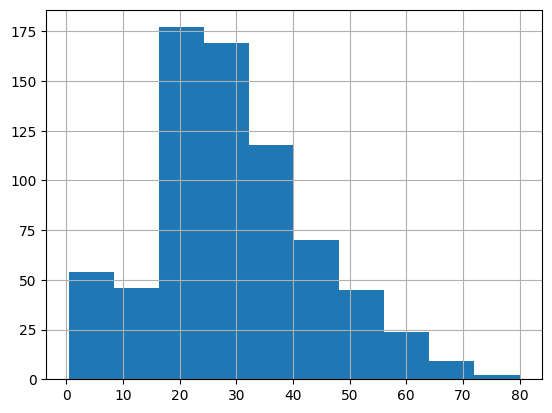

In [7]:
"""
Before I fill Age, I will check to see if it has any extreme outliers, if any, so I can choose whether 
to use mean or median.
"""
df_clean["Age"].hist()

In [8]:
#Skew looks like it's going right, but I have to compute to check.
df_clean["Age"].skew()

np.float64(0.38910778230082704)

In [9]:
#Since both the .skew() and histogram both tell me it's right skewed, using median would be better than mean.
#Why? because the mean would be pulled upward by the age of older people, even though the majority is young.
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [10]:
#As with Embarked, since it's categorical, it's better to use mode.
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

In [11]:
#Checking for any more missing values.
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
#Now, we check for duplicates.
df_clean.duplicated().sum()

np.int64(0)

In [13]:
#Since there isn't any duplicates, we can go to the next step.


#Now, we use a boxplot or the IQR method on the target column and cap extreme values at the 99th percentile
#The target column Survived is binary (0 or 1), so it cannot contain outliers.
#Instead, we inspect numeric feature columns such as Fare for potential outliers.
#SibSp and Parch represent counts of relatives traveling with the passenger.
#While high values may be rare, they correspond to real family groups and are
#therefore not treated as data errors or removed as outliers.
#Age may contain statistically rare values, but these represent valid passenger ages.
#Since they are plausible and not data-entry errors, they are retained.
#Missing values were imputed using the median due to the right-skewed distribution.
#So,time to use the boxplot and IQR method on Fare.

Text(0.5, 1.0, 'Fare Boxplot')

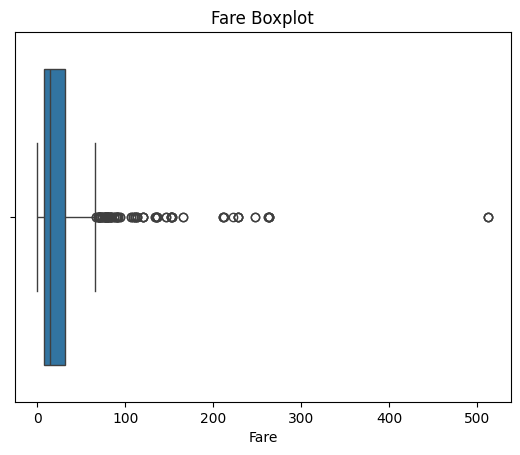

In [14]:
#Boxplot
sns.boxplot(x= df_clean["Fare"])
plt.title("Fare Boxplot")

In [15]:
#IQR
def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

#Computing bounds
lower, upper = iqr_bounds(df_clean["Fare"], k=1.5)

#Detecting outliers
mask_iqr = (df_clean["Fare"] < lower) | (df_clean["Fare"] > upper)
print("Number of Fare outliers:", mask_iqr.sum())

Number of Fare outliers: 116


Text(0.5, 1.0, 'Fare Boxplot')

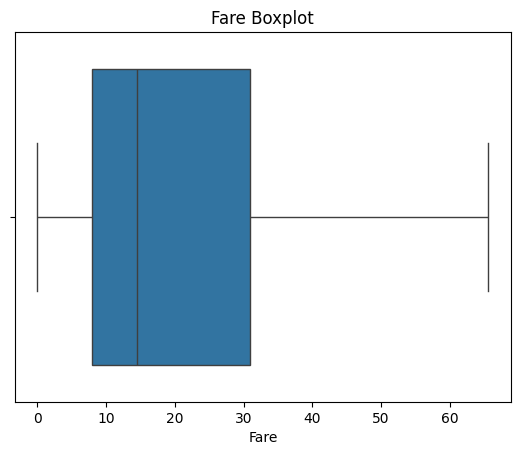

In [16]:
#Finally, we cap
df_capped = df_clean.copy()
df_capped["Fare"] = df_capped["Fare"].clip(lower=lower, upper=upper)

#Boxplot just to make sure
sns.boxplot(x= df_capped["Fare"])
plt.title("Fare Boxplot")

In [17]:
#Sanity check
df_capped.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [18]:
#Now, we make a function that does all we just did.
#I will be using the function display() from the library IPython.display to make it easier to show 
#the data in the clean_data() function.

df = pd.read_csv("train.csv")

def clean_data(df):
    import numpy as np
    from IPython.display import display
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("-----Checking First Five Rows-----")
    display(df.head())
    print("-----Checking Shape-----")
    print(df.shape)
    print("-----Inspecting DataFrame-----")
    df.info()
    print("-----Finding Missing Values And Solving if there is-----")
    print(df.isnull().sum())
    df_clean2 = df.copy()
    # We will drop columns with more than 50% missing values
    # Or fill numeric columns with median/mean based on skew
    # Or fill categorical columns with mode
    missing_pct = df_clean2.isnull().mean() * 100
    for col in df_clean2.columns:
        if df_clean2[col].isnull().sum() > 0:
            if missing_pct[col] > 50:
                df_clean2 = df_clean2.drop(columns=[col])
            elif df_clean2[col].dtype in ["int64", "float64"]:
                skew_value = df_clean2[col].dropna().skew()
                if abs(skew_value) < 0.2:
                    df_clean2[col] = df_clean2[col].fillna(df_clean2[col].mean())
                else:
                    df_clean2[col] = df_clean2[col].fillna(df_clean2[col].median())
            else:
                df_clean2[col] = df_clean2[col].fillna(df_clean2[col].mode()[0])
    #Just in case there remains missing, we'll make an if func that makes sure
    remaining_missing = df_clean2.isnull().sum()
    print("----- Rechecking for Missing Values after Solving -----")
    print(remaining_missing)
    if remaining_missing.sum() == 0:
        print("All missing values handled successfully.")
    else:
        print("Some missing values still remain.")
    print("-----Checking Duplicates-----")
    duplicate_count = df_clean2.duplicated().sum()
    print("Number of duplicate rows:", duplicate_count)
    if duplicate_count > 0:
        df_clean2 = df_clean2.drop_duplicates()
        print("Duplicates were found and removed.")
    else:
        print("No duplicates found, let's move on.")
    print("-----Checking Outliers using IQR Method-----")
    # In Titanic, the target column 'Survived' is binary, so it cannot have outliers.
    # Therefore, we check the numeric feature 'Fare' instead.
    def iqr_bounds(series, k=1.5):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        return lower, upper
    lower, upper = iqr_bounds(df_clean2["Fare"], k=1.5)
    mask_iqr = (df_clean2["Fare"] < lower) | (df_clean2["Fare"] > upper)
    print("Number of Fare outliers detected:", mask_iqr.sum())
    print("-----Capping Fare Outliers-----")
    df_clean2["Fare"] = df_clean2["Fare"].clip(lower=lower, upper=upper)
    print("Fare outliers have been capped using the IQR bounds.")
    print("-----Final Shape After Cleaning-----")
    print(df_clean2.shape)
    print("-----Final DataFrame Info-----")
    df_clean2.info()
    print("-----First Five Rows After Cleaning-----")
    display(df_clean2.head())
    return df_clean2

df_final = clean_data(df)
clean_data(df)

-----Checking First Five Rows-----


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


-----Checking Shape-----
(891, 12)
-----Inspecting DataFrame-----
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
-----Finding Missing Values And Solving if there is-----
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Par

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


-----Checking First Five Rows-----


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


-----Checking Shape-----
(891, 12)
-----Inspecting DataFrame-----
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
-----Finding Missing Values And Solving if there is-----
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Par

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [19]:
#Let's now do the 3 Sanity Checks

print("-----Running Final Sanity Checks-----")

# Check 1: No nulls in key columns
key_cols = ["Survived", "Age", "Fare", "Embarked"]

if df_final[key_cols].isnull().sum().sum() == 0:
    print("Check 1 Passed: No missing values in key columns.")
else:
    print("Check 1 Failed: Missing values still exist in key columns.")

# Check 2: Target column values valid
if df_final["Survived"].isin([0,1]).all():
    print("Check 2 Passed: Target column values are valid (0 or 1).")
else:
    print("Check 2 Failed: Unexpected values in target column.")

# Check 3: Correct number of columns
expected_cols = 11

if df_final.shape[1] == expected_cols:
    print("Check 3 Passed: Correct number of columns.")
else:
    print("Check 3 Failed: Column count changed unexpectedly.")

-----Running Final Sanity Checks-----
Check 1 Passed: No missing values in key columns.
Check 2 Passed: Target column values are valid (0 or 1).
Check 3 Passed: Correct number of columns.


In [20]:
#Let's move our cleaned DataFrame to a new csv, so that we can use it in the next phases
df_final.to_csv("titanic_cleaned.csv", index=False)